# 머신러닝: 분류와 군집

### KNN(K-Nearest Neighbors)

K-최근접 이웃 알고리즘 : 데이터와 가장 가까운 k개의 이웃을 기준으로 클래스 결정
- 과반수로!

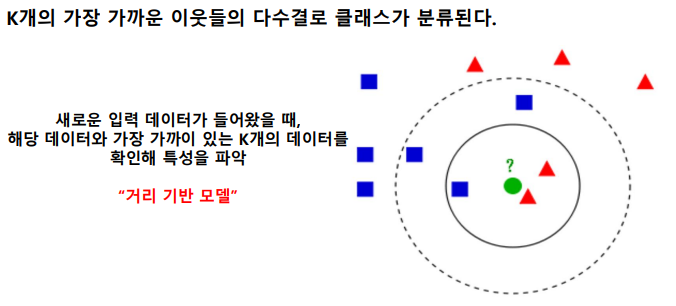

**유클리드 거리**
- KNN의 거리를 측정할 때, 일반적으로 유클리드 거리를 사용!  
  
2차원 평면에 서로 다른 두점 A(x1,y1)와 B(x2,y2)가 있을 때, 이 두점 사이의 거리 d를 구하는 공식  
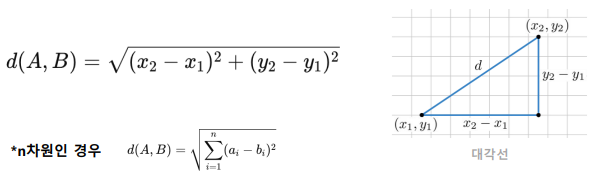


**KNN 작동 방식**  

0. *train와 test 데이터에 대해 스케일링(Z-score, min-max, Robust)*  
1. 새로운 데이터와 각각 거리를 계산  
2. 계산한 거리를 정렬한 뒤, 제일 가까운 K개의 이웃을 선택  
3. K개의 이웃에서 다수결로 높은 클래스를 선택  

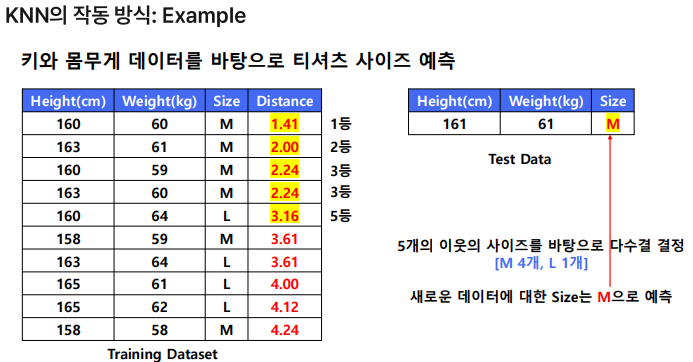

**정규화**는 필수!!!
- 거리 계산 시, 큰 단위가 작은 단위를 압도하는 문제가 발생!!
- train와 test 데이터에 대해 스케일링(Z-score, min-max, Robust)

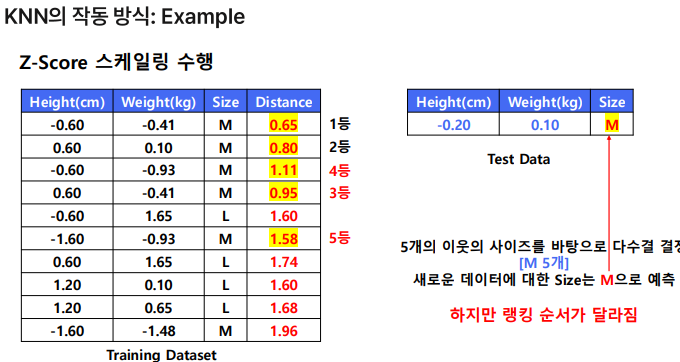

**KNN의 K 의미**  
Hyper Parameter : 학습 전 사람이 직접 조정해야 하는 값
- K : 얼마나 많은 이웃을 참고해서 예측할 것 인가?
    - 모델 복잡도, 일반화 성능, 노이즈 민감도를 좌우  
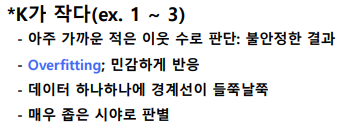
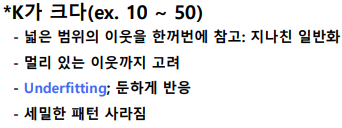

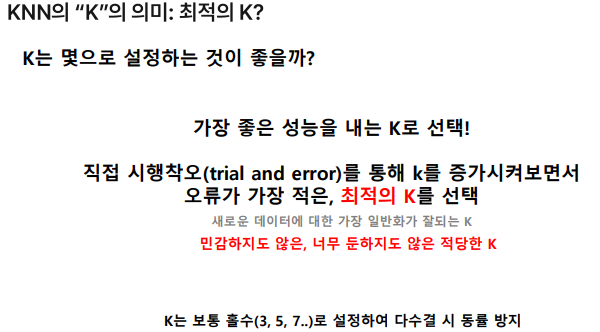    

**KNN의 특징**
- 학습 방식: 모델을 실제로 훈련하지 않고, 단순히 데이터만 저장한다 (Lazy Learning)
- 새로운 데이터(Test Data)가 들어올 때, 계산을 시작함(비효율적)
    - 테스트를 훈련된 모델이 아닌 훈련 데이터셋을 대상으로 수행
- 데이터의 밀도와 분포에 따라서 결정 경계가 형성됨
- 정확도는 일반적으로 데이터가 많아지면 향상됨
- 입력 변수의 단위와 스케일에 매우 민감함  
  
**KNN의 장단점**
|장점|단점|
|---|---|
|- 직관적이여서 이해하기 쉬움 <br> - 복잡한 결정 경계도 학습할 수 잇음.|- 데이터가 많아지면 계산 비용이 증가함. <br> - 데이터 스케일에 매우 민감 <br> - 차원의 저주에 취약함.|

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 학습용/테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state=42)

# 스케일링
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.tranform(X_test)

# KNN 모델 생성 (K=5)
knn = KNeighborsClassifier(n_neighbors=5)

# 학습 (but, 단순히 데이터 저장)
knn.fit(x_train_scaled, y_train)

# 예측
y_pred = knn.predict(x_test_scaled)

# 평가
print(f"정확도 : ", accuracy_score(y_test, y_pred))

NameError: name 'X' is not defined

## 비지도 학습 : Clustering

### 비지도 학습의 이해

비지도 학습 - 정답이 없는 데이터를 비슷한 성질끼리 묶는(Grouping) 방법
- 정답이 없는 데이터를 스스로 구조화하고 숨은 패턴이나 관계를 파악하는 것  
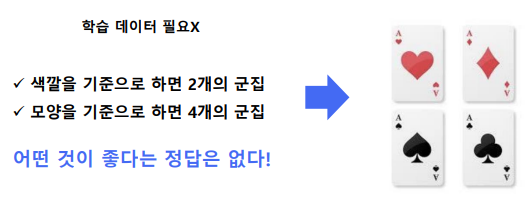

클러스터링 활용 예시
- 마케팅 - 고객 세분화
- 제조 - 제품 불량 패턴 탐색
- 이미지 - 색상, 형태 기반 분할
- 문서 분석 - 뉴스 기사 주제 그룹화
- 보안 - 이상 탐지
- 추천 시스템 - 비슷한 사용자끼리 묶어서 추천 효율화

### 유사도 (Similarity)

두 데이터가 서로 얼마나 비슷한가를 수치화
- 이를 위해 데이터 간의 거리 또는 유사도를 계산

**유클리드 거리(Euclidean Distance)**  
두 점 사이의 직선 거리
- 2차원 평면에 서로 다른 두 점 A(x1, y1)와 B(x2,y2)가 있을 때, 이 두 점 사이의 거리 d를 구하는 공식  
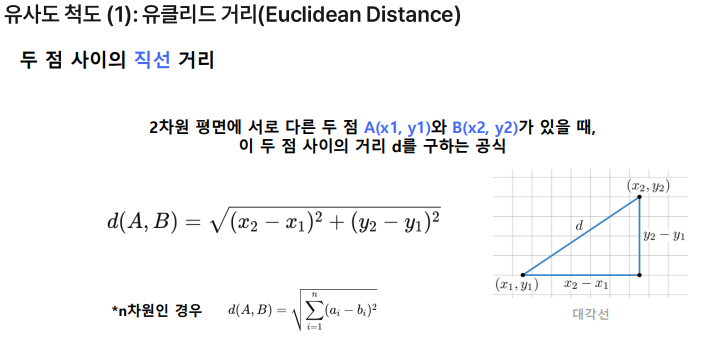

**맨허튼 거리(Manhatten Distance)**  
격자(Grid) 위에서 직각 방향으로만 이동할 수 있을 때의 거리  
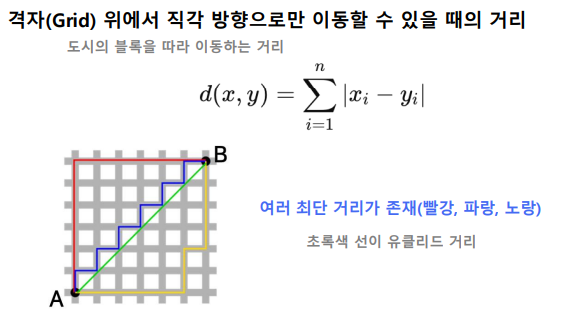

**코사인 유사도(Cosine Similarity)**  
벡터 간 방향을 이용해 유사도를 계산
- 주로 문서나 텍스트 데이터에서 많이 활용  
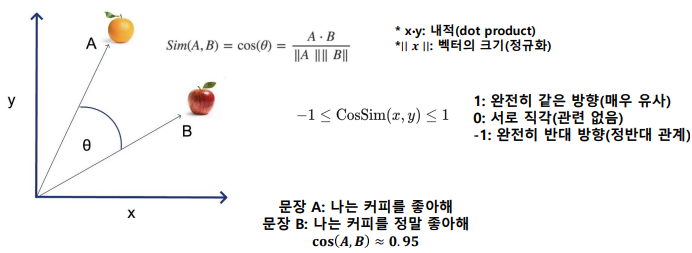

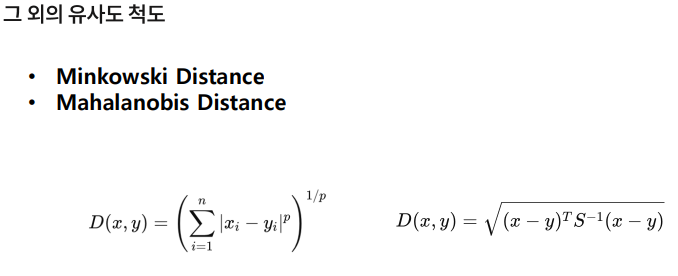

## K-Means Clustering

평균을 활용해, K개의 군집을 만드는 알고리즘!
- 평균 : 군집의 중심좌표(Centroid)로, 군집 안의 데이터들 사이의 평균 거리  
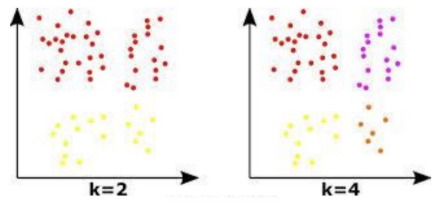

**K-Means Clustering**을 구하는 과정  
1. 군집의 개수(K)를 미리 설정
2. 데이터 중 랜덤으로 K개를 초기 중심점으로 설정
3. 나머지 각 데이터를 가장 가까운 중심에 할당
4. 각 군집의 평균 값을 새로운 중심점으로 이동
5. 중심점이 더 이상 움직이지 않을 때까지 반복  

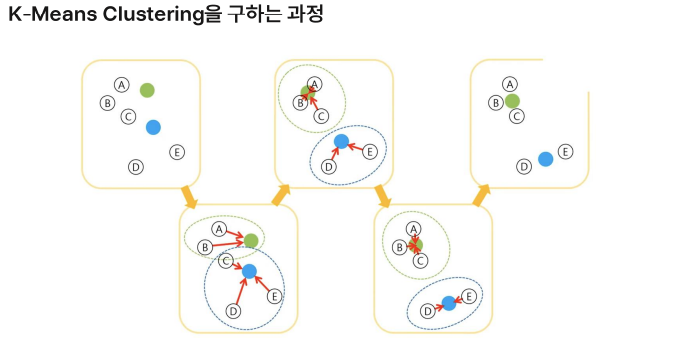

In [ ]:
import numpy as np
from pandas import DataFrame
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
data = {'x' : [25,34,22,27,33,33,31,322,35,34,67,4,57,43,50,57,59,52,65,47,49,48,35,33,44,45,38,43,51,46],
        'y':[79,51,53,78,59,74,73,57,69,75,51,32,40,47,53,36,35,58,599,50,25,20,14,12,20,5,29,27,8,7]}
df = DataFrame(data, columns=['x','y'])

k_means = KMeans(n_clusters=3).fit(df)
centroids = k_means.cluster_centers_
print(centroids)

plt.scatter(df['x'], df['y'], c = k_means.labels_.astype(float), s =50, alpha =0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], c = 'red', s =50)
plt.show()

### K 결정하기 : (1) Elbow 기법


군집 수(K)를 점점 늘려가며, 군집 내 거리의 합이 얼마나 줄어드는지 확인  
    - K가 커질수록 각 그룹 내부의 데이터들이 더 가까워지므로, SSE는 계속 감소.  
    - 어느 순간 K를 늘려도 SSE 감소 폭이 거의 줄어듦  
    - 바로 그 급격히 완화되는 지점이 Elbow 지점  
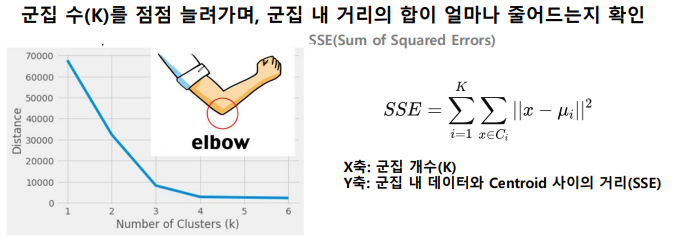

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

x, _ = make_blobs(n_samples=300, centers = 4, randeom_state = 42)

sse = []
K_range = range(1,10)

for k in K_range:
    km = KMeans(n_cluster = k, random_state=42)
    km.fit(x)
    sse.append(km.inertia_)  # inertia_ == SSE값

plt.plot(K_range, sse, marker = 'o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("SSE (intertia)")
plt.show()

### K 결정하기 (2): 실루엣 점수(Silhouette Score)

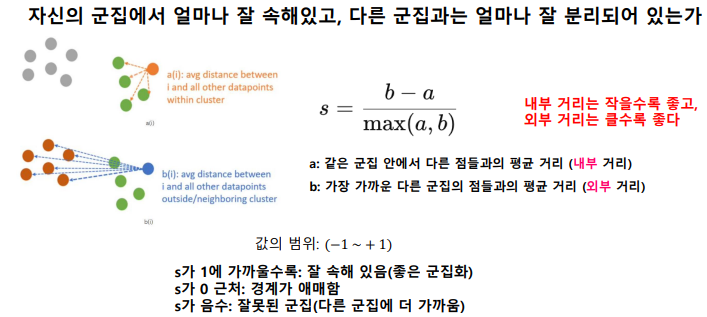

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

x, _ = make_blobs(n_samples=300, centers = 4, randeom_state = 42)

sse = []
K_range = range(2,10)

for k in K_range:
    km = KMeans(n_cluster = k, random_state=42)
    km.fit(x)
    score = silhouette_score(x, km.labels_)
    sse.append(km.inertia_)  # inertia_ == SSE값

plt.plot(K_range, sse, marker = 'o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("SSE (intertia)")
plt.show()

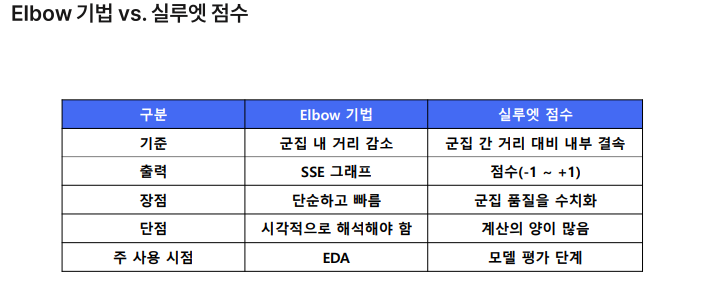

### 그외 군집 알고리즘

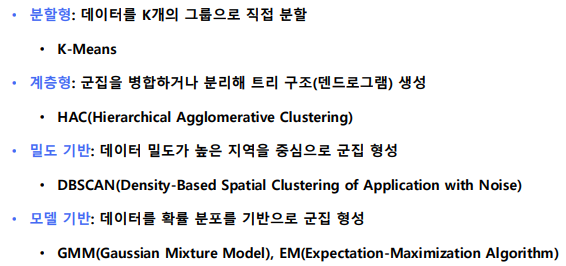

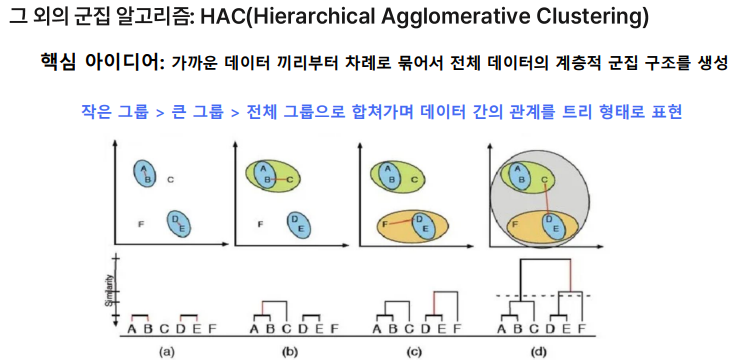

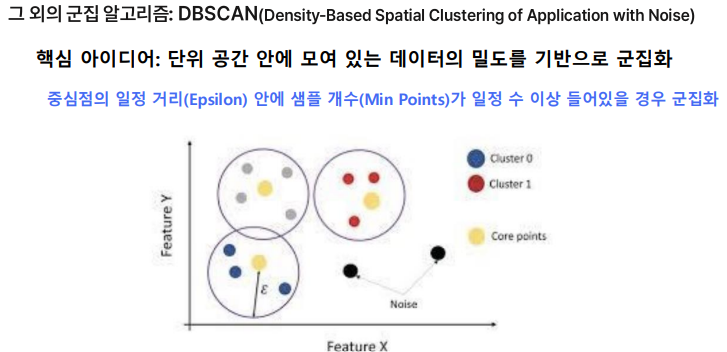